# BONTAM Valuation Tool


This code was developed by:

- Eric Ritondale
- Ivan Baumann Fonay
- Juan Aramis Delich
- Agustin Isern
- Gaston Gomez

Note: technically average risk aversion across maturities is a biased estimator and doesn't minimize the log likehood of that being the true risk aversion coefficient
docs: (insert doc link here)

c:\Users\ggomez\Documents\BONTAM_Project\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bcra.gob.ar'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


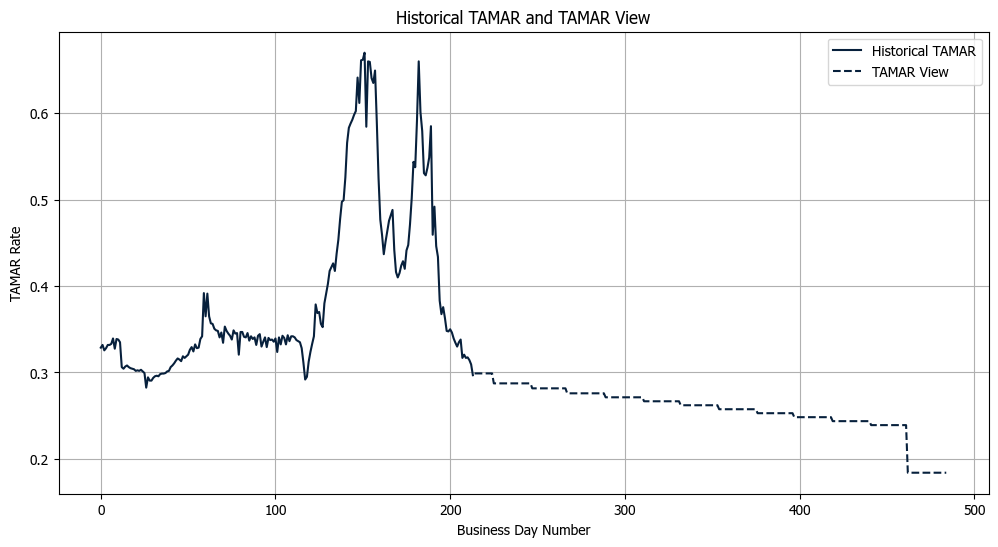

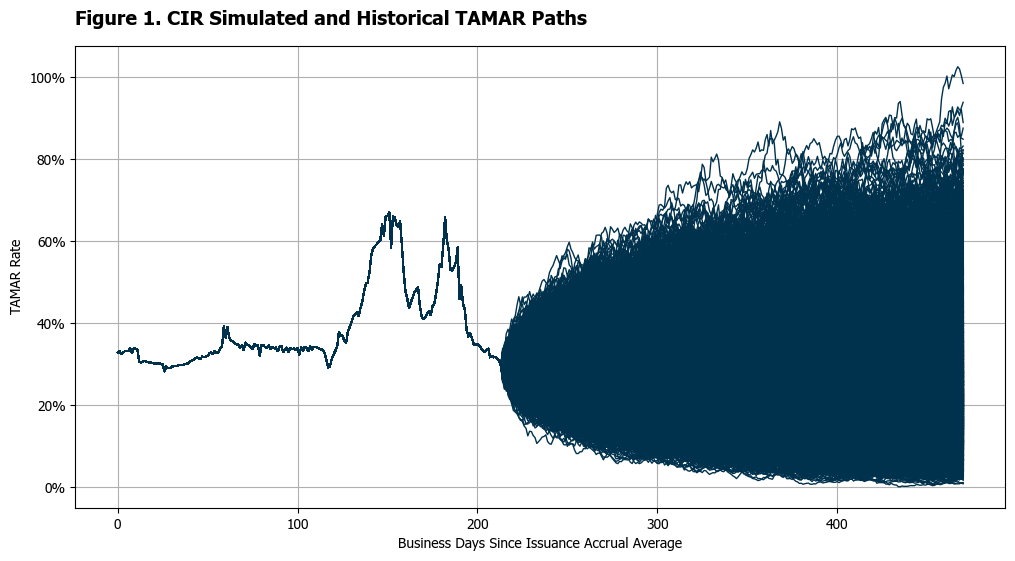

149.5801046089353
total accrual days in days 360: 407
total days left to simulate in business days:59
total days already observed in business days:214
guaranteed terminal value 135.2380799704342
guarrantee present value = 125.08473912908268
first five examples of VPV after applying floor: [149.9691759  149.68495897 149.95987976 147.53004398 150.19150498]
average VPV with floor (no discount)150.4378802186836
non discounted option value: 15.199800248249392
value of discounted option = 14.05863680763655
market implied option value = 13.265260870917317
simulated discounted risk neutral fair value = 139.14337593671925
trading price = 138.35
difference in market price to house view = 0.793375936719233
variance in payment = 2.5959119260785344
estimated risk aversion coefficient = 0.3056251364882615


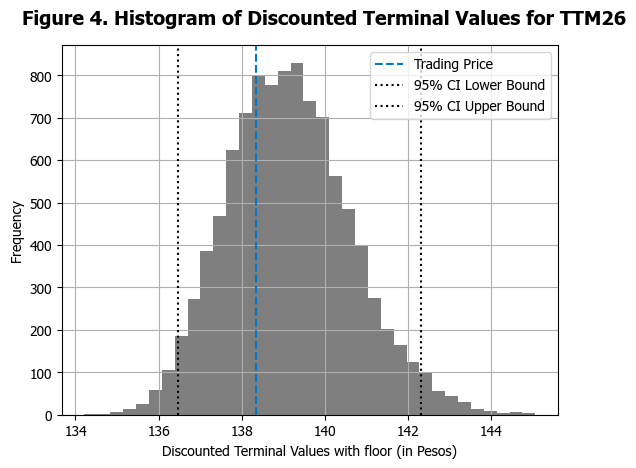

total accrual days in days 360: 511
total days left to simulate in business days:130
total days already observed in business days:214
guaranteed terminal value 144.62933817985532
guarrantee present value = 123.45566563198697
first five examples of VPV after applying floor: [163.72926629 158.20004243 166.66172232 154.14047407 164.34573991]
average VPV with floor (no discount)163.09736522737938
non discounted option value: 18.468027047524032
value of discounted option = 15.76431587639793
market implied option value = 13.194334368013031
simulated discounted risk neutral fair value = 139.21998150838493
trading price = 136.65
difference in market price to house view = 2.569981508384899
variance in payment = 28.786274072741577
estimated risk aversion coefficient = 0.08927801847125834


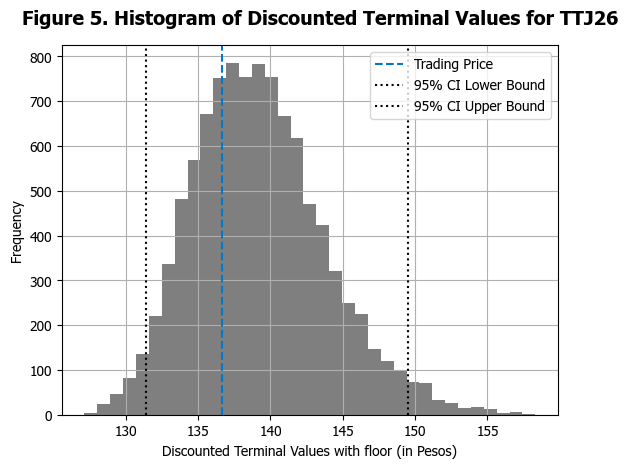

total accrual days in days 360: 586
total days left to simulate in business days:183
total days already observed in business days:214
guaranteed terminal value 152.09570515319578
guarrantee present value = 122.54713716036241
first five examples of VPV after applying floor: [174.68681483 161.83830596 178.67723764 158.3314039  175.71212548]
average VPV with floor (no discount)172.61150704330166
non discounted option value: 20.515801890105887
value of discounted option = 16.530070889571086
market implied option value = 12.052862839637584
simulated discounted risk neutral fair value = 139.0772080499335
trading price = 134.6
difference in market price to house view = 4.477208049933502
variance in payment = 82.49975128506017
estimated risk aversion coefficient = 0.0542693520912986


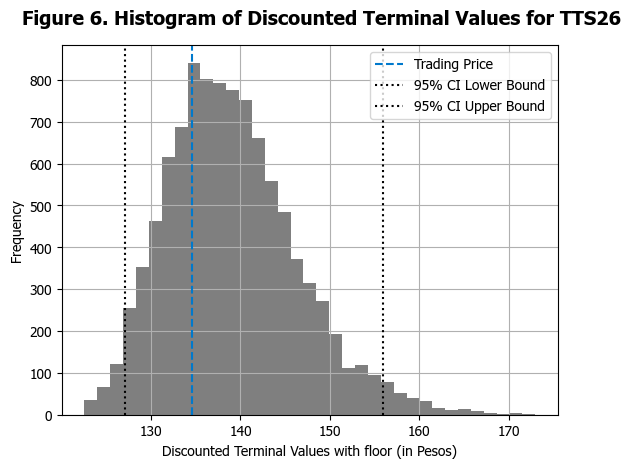

total accrual days in days 360: 676
total days left to simulate in business days:245
total days already observed in business days:214
guaranteed terminal value 161.14366342849303
guarrantee present value = 121.15806640249907
first five examples of VPV after applying floor: [186.11547403 167.508417   197.91634917 161.31138863 189.0563555 ]
average VPV with floor (no discount)184.6948769642427
non discounted option value: 23.551213535749664
value of discounted option = 17.707301874081995
market implied option value = 11.591933597500926
simulated discounted risk neutral fair value = 138.86536827658108
trading price = 132.75
difference in market price to house view = 6.115368276581069
variance in payment = 205.08813020858875
estimated risk aversion coefficient = 0.029818245796874393


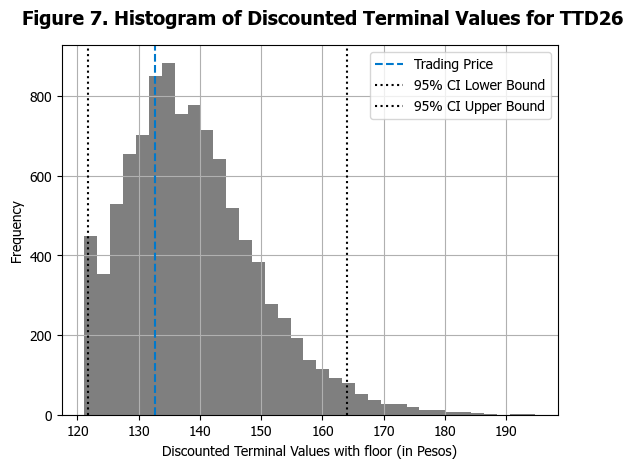

[149.5801046089353, 160.08661053427218, 167.0547545050428, 176.56126377146614]
[np.float64(0.5323885619986242), np.float64(0.5611547507392964), np.float64(0.6117792418139468), np.float64(0.5679541171896878)]
0.5683191679353887


,TAMAR Observations Left to Accrue,Trading Price,Puente Risk-Neutral Fair Value,Puente Risk-Averse Discounted Price
Bond Name,,,,
BONTAM Mar-26 (TTM26),60,138.350,139.143,138.296
BONTAM JUN-26 (TTJ26),131,136.650,139.220,136.617
BONTAM SEP-26 (TTS26),186,134.600,139.077,134.918
BONTAM DEC-26 (TTD26),246,132.750,138.865,132.746


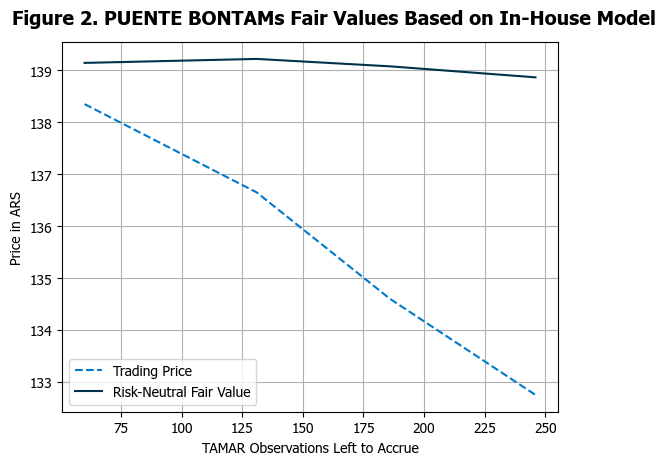

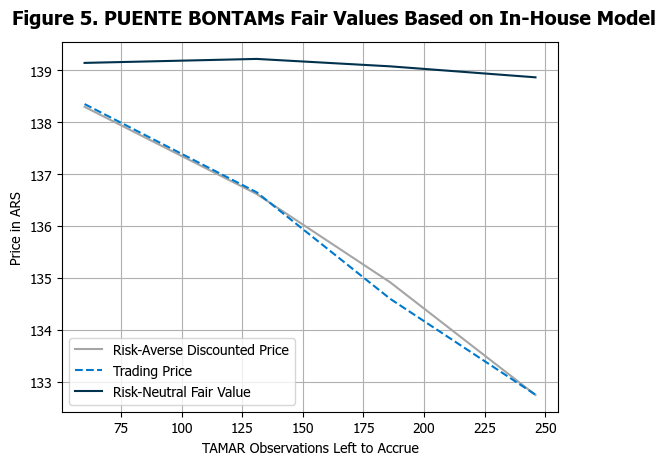

In [8]:

# %%
from datetime import date

TTM26_price = 138.35#138.35
TTJ26_price = 136.65#136.75
TTS26_price = 134.6#134.5
TTD26_price = 132.75#132.55

discount_rate_table = {
    1: 0.02322,
    2: 0.02332,
    3: 0.02333,
    4: 0.02333
}

emission_date = date(2025, 1, 29) #emission date for all bonds in this code is the 29th of January 2025
tamar_start_date = date(2025, 1, 15) # average starts counting 10 business days before emission

M = 10000# Number of paths to simulated
#tuned simulation parameters
sigma = 0.3 # 0.1428
alpha = 0.5
theta = 0.21 # Long-term rate for CIR
kappa = 0.5  # Mean reversion for CIR

interest_simulation_type = 'CIR' # should be 'CIR' 'bk' 'hw' or 'basic'


# %%
# @title
import numpy as np
import pandas as pd
import math as mt
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize_scalar, minimize
from scipy.stats import ncx2
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
import warnings
from datetime import date
import seaborn as sns
import requests
import io
from pandas.tseries.offsets import CustomBusinessDay
# Suppress specific warnings for cleaner output
warnings.filterwarnings("ignore", category=RuntimeWarning)

seed=123

def get_tamar_daily():
    ''' this function uses a request to the BCRA website to download the daily TAMAR
    returns the data as a pandas dataframe, since the beginning of measurement
    note: TAMAR is only published on business days
    '''
    BCRA_DIAR_PAS_URL = "https://www.bcra.gob.ar/Pdfs/PublicacionesEstadisticas/diar_pas.xls"
    # Define headers to mimic a browser request
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    # 1. Download the Excel file with added headers
    resp = requests.get(BCRA_DIAR_PAS_URL, verify=False, headers=headers)
    resp.raise_for_status()

    # 2. Load into pandas, specifying the engine for .xls files
    xls = pd.ExcelFile(io.BytesIO(resp.content), engine='xlrd')

    # Use the specified sheet name
    sheet_name = 'Totales_diarios'
    df = xls.parse(sheet_name, header=35)

    # Clean / standardize columns by stripping whitespace and replacing newlines
    df.columns = [str(c).strip().replace('\n', ' ') for c in df.columns]

    # Identify the column 'Ah' (index 33) and the date column (index 0)
    date_col_name = df.columns[0]
    # Column 'AH' is at index 33
    tamar_col_name = df.columns[33]

    out = df[[date_col_name, tamar_col_name]].copy()

    # Convert date column to datetime objects, specifying dayfirst=True for Argentinian format
    out[date_col_name] = pd.to_datetime(out[date_col_name], errors='coerce', dayfirst=True)

    # Drop rows where date conversion failed (e.g., non-data rows below the actual data)
    out.dropna(subset=[date_col_name], inplace=True)

    # Set date column as index and sort
    out = out.sort_values(date_col_name).set_index(date_col_name)

    # Rename the data column to 'TAMAR' for consistency
    out.rename(columns={tamar_col_name: 'TAMAR'}, inplace=True)

    return out

def simulate_trajectories (sigma, r0, T_years, N, M ,seed = 123):
    """
    This function aims to simulate several interst rate paths under a simple model in which the interest rate is determined by exogenous normaly distributed shocks.

    params:

    sigma: Annualized volatility
    r0: Initial interest rate
    T: Total time in years
    N: total steps
    seed: Uses 123 as default seed
    Returns:
    - rates: Array of shape (N+1, M) with interest rate paths
    """
    dt = T_years/N
    np.random.seed(seed)
    trajectories = np.zeros((N+1,M))
    trajectories [0, :] = r0

    for m in range(M):
        for t in range (1, N+1):
            dW = np.random.normal(0, np.sqrt(dt))
            # Use -drift to ensure that a positive drift parameter makes rates fall.
            #r_t = trajectories[t - 1, m]
            dr_t = (sigma) * dW
            # Enforce non-negativity.
            trajectories[t, m] = max(0, trajectories[t - 1, m] + dr_t)
    return trajectories

def simulate_cir_trajectories(kappa, theta, sigma, r0, T_years, N, M, seed=123):
    """
    This function calculates the rates trajectories under a CIR model, which incorporates a mean reversion aspect and a long term rate view.

    This option allows us to set a mean and a long term view that might incorporate rates decreasing.

    params:

    kappa:
    theta:
    sigma: Annualized volatility
    r0: Starting rate
    T_years: Time in years
    N_steps: Ammount of working days
    M: Ammount of simulations
    Returns:
    - rates: Array of shape (N+1, M) with interest rate paths
    """


    dt = T_years / N
    np.random.seed(seed)
    rates_CIR = np.zeros((N + 1, M))
    rates_CIR[0, :] = r0

    for m in range(M):
        for t in range(1, N + 1):
            r_t = rates_CIR[t - 1, m]
            dW = np.random.normal(0, np.sqrt(dt))
            drift = kappa * (theta - r_t) * dt
            diffusion = sigma * np.sqrt(max(r_t, 0)) * dW
            rates_CIR[t, m] = max(r_t + drift + diffusion, 0)
    return rates_CIR

def simulate_HW_trajectories(r0, alpha, sigma, TAMAR_view, M ,T_years, N, seed=123):

    """
    Simulates M Hull–White interest rate trajectories over N time steps (total time = T_years).

    Parameters:
    - r0: Initial interest rate
    - alpha: Mean reversion speed
    - sigma: Volatility
    - TAMAR_view: List or array of theta(t), expected mean rate path (length N)
    - M: Number of simulation paths
    - T_years: Total simulation time in years
    - N: Number of time steps
    - seed: Random seed for reproducibility

    Returns:
    - rates: Array of shape (N+1, M) with interest rate paths


    """
    dt= T_years/N
    np.random.seed (seed)
    rates_HW = np.zeros((N+1, M))
    rates_HW [0,:] = r0

    for m in range (M):
        for t in range (1, N+1):
            r_t = rates_HW[t - 1, m]
            theta_t = TAMAR_view[t - 1]
            dW = np.random.normal(0, np.sqrt(dt))
            mean_reversion = alpha * (theta_t - r_t) * dt
            diffusion = sigma * dW
            rates_HW[t, m] = r_t + mean_reversion + diffusion
    return rates_HW

def simulate_BK_trajectories(r0, alpha, sigma, TAMAR_view, M ,T_years, N, seed=123):

    """
    Simulates M Black–Karasinski interest rate trajectories over N time steps (total time = T_years).

    Parameters:
    - r0: Initial interest rate
    - alpha: Mean reversion speed
    - sigma: Volatility
    - TAMAR_view: List or array of theta(t), expected mean rate path (length N)
    - M: Number of simulation paths
    - T_years: Total simulation time in years
    - N: Number of time steps
    - seed: Random seed for reproducibility

    Returns:
    - rates: Array of shape (N+1, M) with interest rate paths


    """
    dt= T_years/N
    np.random.seed (seed)
    rates_BK = np.zeros((N+1, M))
    rates_BK [0,:] = r0

    for m in range (M):
        for t in range (1, N+1):
            r_t = np.log(rates_BK[t - 1, m])
            theta_t = np.log (TAMAR_view[t - 1])
            dW = np.random.normal(0, np.sqrt(dt))
            mean_reversion = alpha * (theta_t - r_t) * dt
            diffusion = sigma * dW
            x_next = r_t + mean_reversion + diffusion
            rates_BK[t, m] = np.exp(x_next)
    return rates_BK


def average_tamar(observed_TAMAR, simulated_tamar, business_days_till_expiry):
  '''this function takes business days from the most recent TAMAR publication until 10 business days before expiry, as well as the historical TAMAR (automatically started
  january 15th 2025, and a vector of simulated TAMARS into the future. It returns the average TAMAR over that period '''
  if business_days_till_expiry < 1 or business_days_till_expiry > ((simulated_tamar).shape[0] - 1):
        raise ValueError("Problemas de matrix")

    # shape: (days_needed, M); row 0 is t0, so start at 1
  sim_tail = simulated_tamar[1:business_days_till_expiry+1, :]

  observed_matrix = np.tile(observed_TAMAR.reshape(-1, 1), (1, sim_tail.shape[1]))
  full_matrix = np.vstack([observed_matrix, sim_tail])

    # Per-path averages (vector length M); caller must not collapse with np.mean
  return np.mean(full_matrix, axis=0)

def convert_to_tamar_tem(average_tamar):
    '''this function is a helper that takes a TAMAR rate and converts it to a monthly percent return using the equation given by the Argentine Government'''
    return (((1 + average_tamar / (365/32)) ** (365/32)) ** (1/12))-1

def vpv(tamar_tem, accrual_days_360):
  '''usiing the equation for VPV given by the governmnet, this function takes a TAMAR_tem (as a monthly percent) and the accrual days (in days 360) and returns the VPV of the bond'''
  vpv = 100.0 * (1.0 + tamar_tem) ** ((accrual_days_360 /360)*12)
  return vpv

def get_vpv_vector_given_average_tamar_vector(average_tamar_vector,guaranteed_tamar_tem,accrual_days_360):
  '''given an aevrage tamar vector until 10 business days before expiry, a guaranteed tamar_tem rate, and accrual days 360, this returns a vector of VPVs with the floor'''
  variable_vpv_vector = np.zeros(M)
  for i in range(M):
    variable_vpv_vector[i] = vpv(tamar_tem = max(convert_to_tamar_tem(average_tamar_vector[i]),guaranteed_tamar_tem),accrual_days_360 = accrual_days_360)
  return variable_vpv_vector

def get_distance_days_360(first_date, second_date):
    '''this function was created to get the distance between any two days in days 360'''
    distance_years = (second_date.year - first_date.year)
    distance_months = (second_date.month - first_date.month)
    distance_days = (second_date.day - first_date.day)
    return distance_years * 360 + distance_months * 30 + distance_days

def get_distance_days_252(first_date, second_date):
    '''this function was created to get the distance between any two days in days 252. it uses the argentinian holidays dictionary for precision
    args: first date in 'year-month-day
    second date in 'year-mmonth-day
    return the distance between the provided days as an integer, uses the argentinian business days library defined in the code'''
    distance_days_252 = pd.bdate_range(first_date, second_date, freq=ARG_BD).size - 1 #minus 1 since distance in days is inclusive
    return distance_days_252


def discounted_value(non_discount_value, fr_equiv, expiry_date, today = None):
  '''this is a helped method to discount any zero coupon asset to today.
  args: non discount value = value to be discounted
  fr_equiv = this is the equivalent fixed rate you can get over the same period
  expiry_date = this is the date of expiry of the zero coupon asset, should be in the form year-month-day
  today is none by default and if it is none it will run a local dt calc, otherwise you can specify todays date to be more precise
  returns: the discounted value of the instrument
  '''
  expiry_date = pd.to_datetime(expiry_date)
  if today == None:
    today = pd.Timestamp(date.today()) # Convert datetime.date to pandas.Timestamp
    days_360_till_expiry = get_distance_days_360(today, expiry_date) #uses days 360 helper method to ensure consistent discounting
  else:
    today = pd.to_datetime(today) #  convert day to datetime object if it was specified
  discounted_value = non_discount_value/(((1+fr_equiv)**12)**(days_360_till_expiry/360))    #non_discount_value /(( (1 + fr_equiv)**12) ** (days_365_till_expiry/365))
  return discounted_value

def get_terminal_value(expiry_date, guaranteed_tamar_tem, simulation_type):
  '''this function calls all the other helper functions and makes necessary print statements to make it clear what its calculating. It should be clear
  that this function returns non discounted values'''
  expiry_date = pd.to_datetime(expiry_date)
  accrual_days_360 = get_distance_days_360(emission_date, expiry_date) #accrual days is the days from emission to expiry
  print(f'total accrual days in days 360: {accrual_days_360}')
  days_left_252 = get_distance_days_252(most_recent_tamar_date, expiry_date)-10 # days left is the amount of business days left since the most recent TAMAR release until expiry - 10 (since stops 10 days business days before expiry)
  print(f'total days left to simulate in business days:{days_left_252}')
  print(f'total days already observed in business days:{len(observed_TAMAR)}')
  guaranteed_vpv = vpv(guaranteed_tamar_tem, accrual_days_360)
  print(f'guaranteed terminal value {guaranteed_vpv}')
  guaranteed_present_value = discounted_value(guaranteed_vpv,discount_rate,bond_expiry)

  print(f'guarrantee present value = {guaranteed_present_value}')
  guaranteed_vpv_vector = np.full(M, guaranteed_vpv)
  average_tamar_vector = average_tamar(observed_TAMAR, simulation_type, days_left_252)
  #average_tamar_df = pd.DataFrame(average_tamar_vector)
  #average_tamar_mean = average_tamar_df.mean()
  #print(convert_to_tamar_tem(average_tamar_mean))
  #print(f'Average TAMAR accross simulations till expiry {float(average_tamar_mean)}')
  variable_vpv_vector = get_vpv_vector_given_average_tamar_vector(average_tamar_vector, guaranteed_tamar_tem, accrual_days_360)
  discounted_variable_vpv_vector = discounted_value(variable_vpv_vector,discount_rate,bond_expiry)
  vpv_var = np.var(variable_vpv_vector)
  non_discount_option_value = np.mean(variable_vpv_vector-guaranteed_vpv_vector)
  print(f'first five examples of VPV after applying floor: {variable_vpv_vector[:5]}')
  variable_vpv_vector_df = pd.DataFrame(variable_vpv_vector)
  variable_vpv_std = variable_vpv_vector_df.std(ddof=1)
  mean_vpv_with_floor = np.mean(variable_vpv_vector)
  print(f'average VPV with floor (no discount){mean_vpv_with_floor}')
  print(f'non discounted option value: {non_discount_option_value}')
  return float(non_discount_option_value), float(mean_vpv_with_floor), guaranteed_vpv, vpv_var, discounted_variable_vpv_vector


def discounted_data(terminal_values_tuple, discount_rate, bond_expiry, trading_price,bond_name,figure_number):
  non_discount_option_value, vpv_with_floor, guaranteed_terminal_value, vpv_var, discounted_variable_vpv_vector = terminal_values_tuple

  discounted_option = discounted_value(non_discount_option_value,discount_rate,bond_expiry)
  print(f'value of discounted option = {discounted_option}')
  discounted_vpv = discounted_value(vpv_with_floor,discount_rate,bond_expiry)

  guaranteed_present_value = discounted_value(guaranteed_terminal_value,discount_rate,bond_expiry)
  market_implied_option_value = trading_price - guaranteed_present_value
  print(f'market implied option value = {market_implied_option_value}')


  difference_in_view = discounted_vpv - trading_price
  print(f'simulated discounted risk neutral fair value = {discounted_vpv}')
  print(f'trading price = {trading_price}')
  difference_in_option_price = discounted_option - market_implied_option_value
  print(f'difference in market price to house view = {difference_in_option_price}')
  print(f'variance in payment = {float((vpv_var))}')
  print(f'estimated risk aversion coefficient = {float((difference_in_view/(vpv_var)))}')
  discounted_variable_vpv_vector_df = pd.DataFrame(discounted_variable_vpv_vector, columns= [None])
  
  C1_color = (0 / 255, 121 / 255, 204 / 255)
  C2_color = (127 / 255, 127 / 255, 127 / 255)
  C3_color = (0 / 255, 49 / 255, 77 / 255)
  
  ax = discounted_variable_vpv_vector_df.hist(bins=35, color = C2_color)
  ax[0,0].set_ylabel('Frequency', fontsize = 10 )
  ax[0,0].set_xlabel('Discounted Terminal Values with floor (in Pesos)', fontsize = 10)
  ax[0,0].axvline(x=trading_price, color= C1_color, linestyle='--', label='Trading Price')
  # remove vertical gridlines, keep horizontal
  #ax.grid(visible = False ,which = "both" axis = 'x')

  # Calculate 95% confidence interval
  lower_bound = np.percentile(discounted_variable_vpv_vector, 2.5)
  upper_bound = np.percentile(discounted_variable_vpv_vector, 97.5)

  ax[0,0].axvline(x=lower_bound, color='black', linestyle=':', label='95% CI Lower Bound')
  ax[0,0].axvline(x=upper_bound, color='black', linestyle=':', label='95% CI Upper Bound')

  ax[0,0].legend()
  plt.title(f'Figure {figure_number}. Histogram of Discounted Terminal Values for {bond_name}', loc='left', fontweight='bold', fontsize=14, x=-0.08, pad=15)
  plt.show()
  return discounted_vpv, vpv_var**(1/2), non_discount_option_value, vpv_with_floor

# argentina holidays should be in year-month-day format
ARGENTINA_HOLIDAYS = [
    "2024-01-01","2024-02-12","2024-02-13","2024-03-24","2024-03-29",
    "2024-04-01","2024-04-02","2024-05-01","2024-05-25","2024-06-17",
    "2024-06-20","2024-06-21","2024-07-09","2024-10-11","2024-10-12",
    "2024-11-18","2024-12-08","2024-12-25",
    "2025-01-01","2025-03-03","2025-03-04","2025-03-24","2025-04-02",
    "2025-04-18","2025-05-01","2025-05-25","2025-06-16","2025-06-20",
    "2025-07-09","2025-08-17","2025-10-10","2025-11-24","2025-12-08",
    "2025-12-25",
    "2026-01-01","2026-02-16","2026-02-17","2026-04-02","2026-04-03",
    "2026-03-24","2026-05-01","2026-05-25","2026-06-20","2026-07-09",
    "2026-08-17","2026-10-12","2026-11-23","2026-12-08","2026-12-25",
]

ARG_HOLIDAYS_DT = pd.to_datetime(ARGENTINA_HOLIDAYS)

ARG_BD = CustomBusinessDay(holidays=ARG_HOLIDAYS_DT)

# %%
# @title
tamar = get_tamar_daily()
# Create observed_TAMAR_series with date index and scaled values
observed_TAMAR_series = tamar['TAMAR'][tamar_start_date:] / 100

# observed_TAMAR will be the numpy array needed for simulation functions
observed_TAMAR = observed_TAMAR_series.values

# most_recent_tamar_date is the last date of the series used for r0
most_recent_tamar_date = observed_TAMAR_series.index[-1]

# observed_TAMAR_df is simply the series wrapped in a DataFrame for plotting, so it retains the date index
observed_TAMAR_df = pd.DataFrame(observed_TAMAR_series)

TAMAR_view = np.array ([0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.310463,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.298937,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.287418,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.281660,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.275904,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.271301,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.266698,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.262097,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.257496,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.252897,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.248298,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.243701,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.239104,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029,0.184029])

tamars_realized_since_setting_tamar_view = get_distance_days_252('2025-10-20', most_recent_tamar_date) #this assumes in house tamar view was created on october 20th 2025

TAMAR_view = TAMAR_view[tamars_realized_since_setting_tamar_view:] #clip the first tamar views as time moves forward in real life

# Determine the start date for TAMAR_view
# It should start the business day after the last observed TAMAR
tamar_view_start_date = observed_TAMAR_df.index[-1] + ARG_BD

# Generate business days for TAMAR_view
tamar_view_dates = pd.bdate_range(start=tamar_view_start_date, periods=len(TAMAR_view), freq=ARG_BD)

# Create a Series for TAMAR_view with the generated dates
TAMAR_view_series_indexed = pd.Series(TAMAR_view, index=tamar_view_dates)

# Concatenate observed_TAMAR_df and TAMAR_view_series_indexed into a single DataFrame for plotting
# Aligning them by converting TAMAR_view_series_indexed to a DataFrame with the same column name
combined_historical_and_view = pd.concat([observed_TAMAR_df, pd.DataFrame(TAMAR_view_series_indexed, columns=['TAMAR'])])

# Plotting with numerical index
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(observed_TAMAR_df)), observed_TAMAR_df.values, label='Historical TAMAR', color='#07203C')
plt.plot(np.arange(len(observed_TAMAR_df), len(combined_historical_and_view)), TAMAR_view_series_indexed.values, label='TAMAR View', color='#07203C', linestyle='--')
plt.title('Historical TAMAR and TAMAR View')
plt.xlabel('Business Day Number') # Changed label to reflect numerical index
plt.ylabel('TAMAR Rate')
plt.legend()
plt.grid(True)
plt.show()

# %%
# @title
# create sims
r0 = float(observed_TAMAR[-1])
T_years = (287-tamars_realized_since_setting_tamar_view)/252
N = 287-tamars_realized_since_setting_tamar_view  #  steps


basic = simulate_trajectories(sigma=sigma, r0=r0, T_years=T_years, N=N, M=M)
CIR = simulate_cir_trajectories(sigma=sigma, kappa = kappa, theta=theta, r0=r0, T_years=T_years, N=N, M=M)
hw = simulate_HW_trajectories(r0=r0, alpha=alpha, sigma=sigma, TAMAR_view=TAMAR_view, M=M, T_years=T_years, N=N)
bk = simulate_BK_trajectories(r0=r0, alpha=alpha, sigma=sigma, TAMAR_view=TAMAR_view, M=M, T_years=T_years, N=N)

if interest_simulation_type == 'CIR':
  simulation_type = CIR
elif interest_simulation_type == 'hw':
  simulation_type = hw
elif interest_simulation_type == 'bk':
  simulation_type = bk
elif interest_simulation_type == 'basic':
  simulation_type = basic
else:
 raise ValueError('please choose a valid sim type')

# Get the last date from the historical data
last_observed_date = observed_TAMAR_df.index[-1]

# Generate future business days for the simulation
# The simulation_type array has N+1 rows, where the first row is r0 (at last_observed_date).
# The subsequent N rows are the actual simulated steps.
sim_start_date_for_index = last_observed_date + ARG_BD
sim_dates = pd.bdate_range(start=sim_start_date_for_index, periods=N, freq=ARG_BD)

# Create DataFrame for simulated data with generated dates, excluding the initial r0 row
sim_df_indexed = pd.DataFrame(simulation_type[1:, :], index=sim_dates, columns=[f'Path_{i}' for i in range(M)])

# Prepare historical data for concatenation - duplicate the single column of observed_TAMAR_df M times
historical_expanded = pd.DataFrame({f'Path_{i}': observed_TAMAR_df.iloc[:, 0] for i in range(M)})

# Combine observed and simulated data
combined_df = pd.concat([historical_expanded, sim_df_indexed])
plt.rcParams["font.family"] = "Tahoma"
C3_color = (0 / 255, 49 / 255, 77 / 255)

plt.figure(figsize=(12, 6)) # Make plot larger for better visibility

# Plot using numerical index instead of datetime index
plt.plot(np.arange(len(combined_df)), combined_df.values, color = C3_color, linewidth= 1)
plt.title(f'Figure 1. {interest_simulation_type} Simulated and Historical TAMAR Paths', loc='left', fontweight='bold', fontsize=14, x=0, pad=15)
plt.xlabel('Business Days Since Issuance Accrual Average', fontsize = 10) # Changed label to reflect numerical index
plt.ylabel('TAMAR Rate', fontsize = 10)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.grid(True)
plt.show()

# %%

bond_expiry = pd.to_datetime('2026-03-16')
base_rate = 0.0225
discount_rate = discount_rate_table[1] #0.02322
trading_price = TTM26_price #138.4
TTM26_expected_tv= trading_price/(discounted_value(1,discount_rate,bond_expiry))
print(TTM26_expected_tv)
TTM26_trading_price = trading_price
bond_name = 'TTM26'
figure_number = '4'
terminal_values = get_terminal_value(bond_expiry,base_rate,simulation_type)
TTM26_discounted_vpv, TTM26_var, TTM26_non_discount_option_value, TTM26_vpv_with_floor = discounted_data(terminal_values, discount_rate, bond_expiry, trading_price, bond_name, figure_number)

# %%
bond_expiry = pd.to_datetime('2026-06-30')
base_rate = 0.0219
discount_rate = discount_rate_table[2] #0.02332
trading_price = TTJ26_price #136.8 #136.65
TTJ26_expected_tv= trading_price/(discounted_value(1,discount_rate,bond_expiry))
TTJ26_trading_price = trading_price
bond_name = 'TTJ26'
figure_number = '5'
terminal_values = get_terminal_value(bond_expiry,base_rate,simulation_type)
TTJ26_discounted_vpv, TTJ26_var,TTJ26_non_discount_option_value, TTJ26_vpv_with_floor = discounted_data(terminal_values, discount_rate, bond_expiry, trading_price, bond_name, figure_number)

# %%
bond_expiry = pd.to_datetime('2026-09-15')
base_rate = 0.0217
discount_rate = discount_rate_table[3] #0.02333
trading_price = TTS26_price #134.5 #134.75
TTS26_expected_tv= trading_price/(discounted_value(1,discount_rate,bond_expiry))
TTS26_trading_price = trading_price
bond_name = 'TTS26'
figure_number = '6'
terminal_values = get_terminal_value(bond_expiry,base_rate,simulation_type)
TTS26_discounted_vpv, TTS26_var, TTS26_non_discount_option_value, TTS26_vpv_with_floor = discounted_data(terminal_values, discount_rate, bond_expiry, trading_price, bond_name, figure_number)



bond_expiry = pd.to_datetime('2026-12-15')
base_rate = 0.0214
discount_rate = discount_rate_table[4] #0.02333
trading_price = TTD26_price #132.5 #131.9
TTD26_expected_tv= trading_price/(discounted_value(1,discount_rate,bond_expiry))
TTD26_trading_price = trading_price
bond_name = 'TTD26'
figure_number = '7'
terminal_values = get_terminal_value(bond_expiry,base_rate,simulation_type)
TTD26_discounted_vpv, TTD26_var, TTD26_non_discount_option_value, TTD26_vpv_with_floor = discounted_data(terminal_values, discount_rate, bond_expiry, trading_price, bond_name, figure_number)


# %%
bdays_till_expiry = [60, 131, 186,246]
trading_prices = [TTM26_trading_price, TTJ26_trading_price, TTS26_trading_price, TTD26_trading_price]
risk_neutral_non_discount_option = [TTM26_non_discount_option_value, TTJ26_non_discount_option_value, TTS26_non_discount_option_value, TTD26_non_discount_option_value]
risk_neutral_fair_values = [TTM26_discounted_vpv, TTJ26_discounted_vpv, TTS26_discounted_vpv, TTD26_discounted_vpv]
expected_tvs = [TTM26_expected_tv, TTJ26_expected_tv, TTS26_expected_tv, TTD26_expected_tv]
print(expected_tvs)
variances_in_payment = [TTM26_var, TTJ26_var, TTS26_var, TTD26_var]
non_discounted_terminal_values = [TTM26_vpv_with_floor,TTJ26_vpv_with_floor,TTS26_vpv_with_floor,TTD26_vpv_with_floor]
difference_in_view = [0,0,0,0]
for x in range(0,4):
  difference_in_view[x] = risk_neutral_fair_values[x] - trading_prices[x]


# %%
estimated_risk_aversion_coefficient = [0,0,0,0]
for x in range(0,4):
  estimated_risk_aversion_coefficient[x] = (non_discounted_terminal_values[x]-expected_tvs[x])/(variances_in_payment[x])

print(estimated_risk_aversion_coefficient)
optimal_risk_aversion = np.mean(estimated_risk_aversion_coefficient)
print(optimal_risk_aversion)


# %%
risk_averse_no_discount_prices = [0,0,0,0]

for x in range(0,4):
  risk_averse_no_discount_prices[x] = non_discounted_terminal_values[x]-optimal_risk_aversion*(variances_in_payment[x])



# %%



expiry_lookup_table = {
    1: '2026-03-16',
    2: '2026-06-30',
    3: '2026-09-15',
    4: '2026-12-15'
}

risk_averse_discounted_prices = [0]*4 # Initialize with 4 zeros
for x  in range(1,5):
  # Use x-1 for indexing risk_averse_no_discount_prices and risk_averse_discounted_prices (0-indexed lists)
  # Use x directly for discount_rate_table and expiry_lookup_table (1-indexed dictionaries)
  risk_averse_discounted_prices[x-1] = discounted_value(risk_averse_no_discount_prices[x-1], discount_rate_table[x], expiry_lookup_table[x])



# %%
plt.rcParams["font.family"] = "Tahoma"
threshold = 0.2760
grey_color = (165 / 255, 165 / 255, 165 / 255)
navy_color = (0 / 255, 121 / 255, 204 / 255)
C3_color = (0 / 255, 49 / 255, 77 / 255)



# %%

font_family = 'Tahoma'
data = {
    'TAMAR Observations Left to Accrue': bdays_till_expiry,
    'Trading Price': trading_prices,
    'Puente Risk-Neutral Fair Value': risk_neutral_fair_values,
    'Puente Risk-Averse Discounted Price': risk_averse_discounted_prices,
    'Bond Name': ['BONTAM Mar-26 (TTM26)', 'BONTAM JUN-26 (TTJ26)', 'BONTAM SEP-26 (TTS26)', 'BONTAM DEC-26 (TTD26)']
}
df = pd.DataFrame(data)
df = df.set_index('Bond Name')

# Create a Styler object
styled_df = df.style

# Apply header styling (blue background, white text) and data cell styling (white background, black text)
styled_df = styled_df.set_table_styles([
    {'selector': 'th',
     'props': [('background-color', '#07203C'), ('color', 'white'),('font-size','12pt'),('font-weight', 'bold'), ('font-family','Tahoma'),('text-align', 'center')]},
    {'selector': 'td',
     'props': [('background-color', 'white'), ('font-family','Tahoma'),('color', 'black')]},
    {'selector': 'th.row_heading',
     'props': [('background-color', '#D9D9D9'),('font-family','Tahoma'), ('color', 'black')]}
])

# Set precision for float numbers
styled_df = styled_df.format(precision=3)

# Display the styled DataFrame
display(styled_df)



plt.plot(bdays_till_expiry, trading_prices, color = navy_color, linestyle = '--')
plt.plot(bdays_till_expiry, risk_neutral_fair_values, color = C3_color)
plt.title('Figure 2. PUENTE BONTAMs Fair Values Based on In-House Model', loc='left', fontweight='bold', fontsize=14, x=-0.10, pad=13)
#plt.text( "Annual nominal rate (%) - Incorporating Volatility to the PUENTE Base Case for TAMAR", fontsize=9, ha='left')
plt.legend([ 'Trading Price', 'Risk-Neutral Fair Value'])
plt.xlabel('TAMAR Observations Left to Accrue', fontsize=10)
plt.ylabel('Price in ARS', fontsize = 10)
plt.grid(True)
plt.show()


plt.plot(bdays_till_expiry,risk_averse_discounted_prices, color = grey_color)
plt.plot(bdays_till_expiry, trading_prices, color = navy_color, linestyle = '--')
plt.plot(bdays_till_expiry, risk_neutral_fair_values, color = C3_color)
plt.title('Figure 5. PUENTE BONTAMs Fair Values Based on In-House Model', loc='left', fontweight='bold', fontsize=14, x=-0.10, pad=13)
#plt.text( "Annual nominal rate (%) - Incorporating Volatility to the PUENTE Base Case for TAMAR", fontsize=9, ha='left')
plt.legend(['Risk-Averse Discounted Price', 'Trading Price', 'Risk-Neutral Fair Value'])
plt.xlabel('TAMAR Observations Left to Accrue', fontsize=10)
plt.ylabel('Price in ARS', fontsize = 10)
plt.grid(True)
plt.show()
